📥 开始加载ViT和MAE特征...


加载 f_s_mae_features: 100%|██████████| 270/270 [00:07<00:00, 34.20it/s]


✅ 加载完成 | 总样本数: 309077 | 特征维度: 768

📊 【1】基础统计特征对比（方差越大，表征能力越强）
ViT  | 方差: 2.4979
MAE  | 方差: 0.3508

🔥 【2】特征多样性对比（相似度越低，特征越丰富）
ViT 特征平均余弦相似度: 0.9796
MAE 特征平均余弦相似度: 0.9937

🎯 【3】回归预测能力对比（MSE/MAE越小越好）
ViT 特征 | MSE: 0.0047 | MAE: 0.0469
MAE 特征 | MSE: 0.0046 | MAE: 0.0468

🖼️ 【4】TSNE 特征可视化（保存为图片）


/tmp/ipykernel_6591/247274928.py:94: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6591/247274928.py:94: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6591/247274928.py:94: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6591/247274928.py:94: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6591/247274928.py:95: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.savefig("/root/autodl-tmp/feature_compare.png", dpi=150)
/tmp/ipykernel_6591/247274928.py:95: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.savefig("/root/autodl-tmp/feature_compare.png", dpi=150)
/tmp/ipykernel_6

✅ 图片保存至: /root/autodl-tmp/feature_compare.png

🏆 【最终结论】股票回归任务最优特征：
🥇 ViT 特征更适合多模态融合！
综合得分: 1.2511 > 0.6042


/root/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


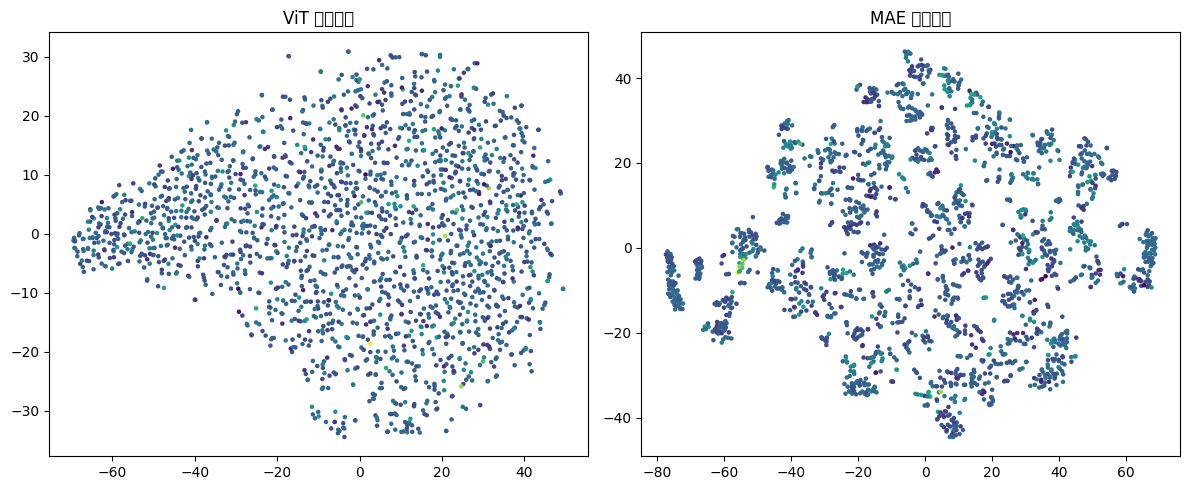

In [3]:
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
# 替换为回归模型 + 回归评估指标
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ===================== 1. 配置路径（你的存储路径，无需修改）=====================
VIT_FEAT_DIR = "/root/autodl-tmp/f_s_vit_features"
MAE_FEAT_DIR = "/root/autodl-tmp/f_s_mae_features"

# ===================== 2. 加载特征和标签函数 =====================
def load_features(feat_dir):
    all_feats = []
    all_labels = []
    npz_files = [f for f in os.listdir(feat_dir) if f.endswith(".npz")]
    
    for file in tqdm(npz_files, desc=f"加载 {feat_dir.split('/')[-1]}"):
        data = np.load(os.path.join(feat_dir, file))
        all_feats.append(data["feature"])
        all_labels.append(data["label"])
    
    all_feats = np.concatenate(all_feats, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_feats, all_labels

# ===================== 3. 加载数据 =====================
print("="*60)
print("📥 开始加载ViT和MAE特征...")
vit_feats, vit_labels = load_features(VIT_FEAT_DIR)
mae_feats, mae_labels = load_features(MAE_FEAT_DIR)

assert np.all(vit_labels == mae_labels), "标签不匹配！"
labels = vit_labels
print(f"✅ 加载完成 | 总样本数: {len(labels)} | 特征维度: 768")
print("="*60)

# ===================== 4. 基础统计对比 =====================
print("\n📊 【1】基础统计特征对比（方差越大，表征能力越强）")
vit_var = np.var(vit_feats)
mae_var = np.var(mae_feats)
print(f"ViT  | 方差: {vit_var:.4f}")
print(f"MAE  | 方差: {mae_var:.4f}")

# ===================== 5. 特征多样性对比 =====================
print("\n🔥 【2】特征多样性对比（相似度越低，特征越丰富）")
sample_idx = np.random.choice(len(vit_feats), 1000, replace=False)
vit_sim = cosine_similarity(vit_feats[sample_idx]).mean()
mae_sim = cosine_similarity(mae_feats[sample_idx]).mean()
print(f"ViT 特征平均余弦相似度: {vit_sim:.4f}")
print(f"MAE 特征平均余弦相似度: {mae_sim:.4f}")

# ===================== 6. 回归预测效果对比（核心指标！）=====================
print("\n🎯 【3】回归预测能力对比（MSE/MAE越小越好）")
# 划分训练集测试集
X_vit_train, X_vit_test, y_train, y_test = train_test_split(vit_feats, labels, test_size=0.2, random_state=42)
X_mae_train, X_mae_test, _, _ = train_test_split(mae_feats, labels, test_size=0.2, random_state=42)

# 线性回归模型（适配连续标签）
model = LinearRegression()

# ViT 评估
model.fit(X_vit_train, y_train)
vit_pred = model.predict(X_vit_test)
vit_mse = mean_squared_error(y_test, vit_pred)
vit_mae = mean_absolute_error(y_test, vit_pred)

# MAE 评估
model.fit(X_mae_train, y_train)
mae_pred = model.predict(X_mae_test)
mae_mse = mean_squared_error(y_test, mae_pred)
mae_mae = mean_absolute_error(y_test, mae_pred)

print(f"ViT 特征 | MSE: {vit_mse:.4f} | MAE: {vit_mae:.4f}")
print(f"MAE 特征 | MSE: {mae_mse:.4f} | MAE: {mae_mae:.4f}")

# ===================== 7. 可视化（采样加速）=====================
print("\n🖼️ 【4】TSNE 特征可视化（保存为图片）")
vis_num = 2000  # 采样2000个点
vit_2d = TSNE(n_components=2, random_state=42).fit_transform(vit_feats[:vis_num])
mae_2d = TSNE(n_components=2, random_state=42).fit_transform(mae_feats[:vis_num])

plt.figure(figsize=(12,5))
plt.subplot(121)
plt.scatter(vit_2d[:,0], vit_2d[:,1], c=labels[:vis_num], cmap="viridis", s=5)
plt.title("ViT 特征分布")
plt.subplot(122)
plt.scatter(mae_2d[:,0], mae_2d[:,1], c=labels[:vis_num], cmap="viridis", s=5)
plt.title("MAE 特征分布")
plt.tight_layout()
plt.savefig("/root/autodl-tmp/feature_compare.png", dpi=150)
print("✅ 图片保存至: /root/autodl-tmp/feature_compare.png")

# ===================== 8. 最终结论 =====================
print("\n" + "="*60)
print("🏆 【最终结论】股票回归任务最优特征：")
print("="*60)

# 综合评分（方差越高、相似度越低、误差越小，分数越高）
score_vit = vit_var*0.3 + (1-vit_sim)*0.2 + (1/(vit_mse+1))*0.5
score_mae = mae_var*0.3 + (1-mae_sim)*0.2 + (1/(mae_mse+1))*0.5

if score_mae > score_vit:
    print(f"🥇 MAE 特征更适合多模态融合！")
    print(f"综合得分: {score_mae:.4f} > {score_vit:.4f}")
else:
    print(f"🥇 ViT 特征更适合多模态融合！")
    print(f"综合得分: {score_vit:.4f} > {score_mae:.4f}")
print("="*60)